# Task 2.2 — Reproduction of One Contribution (20 marks)

**Paper**: *Learning to Grade Short Answer Questions using Semantic Similarity Measures and Dependency Graph Alignments* (Mohler, Bunescu & Mihalcea, ACL 2011)

---

## Contribution Being Reproduced

We reproduce the paper's contribution of **combining multiple similarity features with SVR for automated short-answer grading** (Section 3.4, Table 7 — "BOW / SVR" row). Specifically, we replicate the idea that using supervised learning (SVR with a linear kernel) to combine heterogeneous textual similarity features yields better grading performance than any individual similarity measure.

**Evaluation metrics**: RMSE and Pearson correlation (ρ), as used in the paper (Section 5).

## Setup and Configuration

In [1]:
# ── Hyperparameters & Configuration ──────────────────────────────
RANDOM_SEED = 42
SVR_C = 1.0                # SVR regularisation parameter
SVR_EPSILON = 0.1          # SVR epsilon-tube width
TEST_SPLIT = 0.2           # 80/20 train-test split
RESULTS_DIR = "results"

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

np.random.seed(RANDOM_SEED)

sys.path.insert(0, os.path.abspath("."))
from grading_model import ShortAnswerGrader, FeatureConfig, build_toy_short_answer_dataset

os.makedirs(RESULTS_DIR, exist_ok=True)

## Step 1: Load the Dataset

We load the synthetic dataset generated in Task 2.1. The paper uses 2,273 student answers graded on a [0, 5] scale (Section 4). Our synthetic dataset follows the same structure but with algorithmically generated grades.

In [3]:
# Load the dataset generated in Task 2.1
data_path = os.path.join("data", "short_answer_dataset.csv")
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
else:
    df = build_toy_short_answer_dataset(n_per_question=50, random_state=RANDOM_SEED)
    os.makedirs("data", exist_ok=True)
    df.to_csv(data_path, index=False)

# Train-test split
train_df, test_df = train_test_split(df, test_size=TEST_SPLIT, random_state=RANDOM_SEED)
print(f"Training set: {len(train_df)} samples")
print(f"Test set:     {len(test_df)} samples")
print(f"Total:        {len(df)} samples")

Training set: 120 samples
Test set:     30 samples
Total:        150 samples


This loads the dataset and creates an 80/20 train-test split. The paper uses 12-fold cross-validation where each assignment/exam is a fold (Section 5.4). We simplify to a single split for the toy dataset.

## Step 2: Feature Engineering

The paper computes a 30-dimensional feature vector $\psi(A_i, A_s) = [\psi_G(A_i, A_s) | \psi_B(A_i, A_s)]$ combining graph alignment features and BOW similarity features (Section 3.4). In our simplified reproduction, we compute 6 features:

**Surface features** (analogous to $\psi_B$ — Section 3.3, Table 5):
1. TF-IDF cosine similarity — corresponds to the tf*idf measure in Table 5
2. Word overlap ratio — simplified version of the WordNet-based measures
3. Length difference — captures answer completeness

**Semantic features** (analogous to corpus-based features — Section 3.3):
4. Sentence embedding cosine similarity (via LSA/TruncatedSVD) — corresponds to the LSA measure in Table 5

**Lightweight structural features** (simplified analogy to $\psi_G$ — Section 3.1–3.2):
5. POS tag overlap ratio — captures syntactic category alignment without full dependency parsing
6. Root verb match — simplified version of the RootMatch feature in Table 2

In [4]:
# Instantiate the full-featured grader
# All features enabled: surface + semantic + structural
# This corresponds to the "Hybrid" model in Table 7 (both BOW and alignment features)
config = FeatureConfig(use_semantic=True, use_structural=True)
grader = ShortAnswerGrader(feature_config=config, random_state=RANDOM_SEED)

print(f"Feature configuration: semantic={config.use_semantic}, structural={config.use_structural}")
print(f"SVR kernel: linear (same as paper — Section 5.4, footnote 11)")
print(f"SVR C={SVR_C}, epsilon={SVR_EPSILON}")

Feature configuration: semantic=True, structural=True
SVR kernel: linear (same as paper — Section 5.4, footnote 11)
SVR C=1.0, epsilon=0.1


The `ShortAnswerGrader` computes all 6 features and feeds them into an SVR with a linear kernel. The paper uses a linear kernel for SVR (Section 5.4, footnote 11: "We also ran the SVR system using quadratic and radial-basis function kernels, but the results did not show significant improvement over the simpler linear kernel").

## Step 3: Training the SVR Model

The paper trains SVR to minimise MSE on the training data, with parameters (C, ε) tuned via grid search on 5-fold cross-validation within the training set (Section 5.4). We use a simplified approach with fixed C=1.0 and ε=0.1.

In [5]:
# Train the model (Section 3.4: SVR with linear kernel)
grader.fit(train_df, C=SVR_C, epsilon=SVR_EPSILON)
print("Model trained successfully.")
print(f"Number of support vectors: {grader._svr.n_support_}")

Model trained successfully.
Number of support vectors: [93]


The SVR model has been trained on the feature vectors extracted from training set answer pairs. The linear kernel learns weights $u$ such that predicted grade $g(A_i, A_s) = u^T \psi(A_i, A_s)$ (Section 3.4).

## Step 4: Evaluation

We evaluate using the same metrics as the paper (Section 5): **Pearson's correlation coefficient** (ρ) between predicted and true grades, and **Root Mean Square Error** (RMSE). The paper reports these on a 12-fold cross-validation; we report on our held-out test set.

In [6]:
# Evaluate on test set
results = grader.evaluate(test_df)

print("=" * 50)
print("EVALUATION RESULTS (Full Model — All Features)")
print("=" * 50)
print(f"RMSE:              {results['rmse']:.4f}")
print(f"Pearson corr (ρ):  {results['pearson']:.4f}")
print("=" * 50)

EVALUATION RESULTS (Full Model — All Features)
RMSE:              0.3535
Pearson corr (ρ):  0.9802


## Step 5: Predictions Visualisation

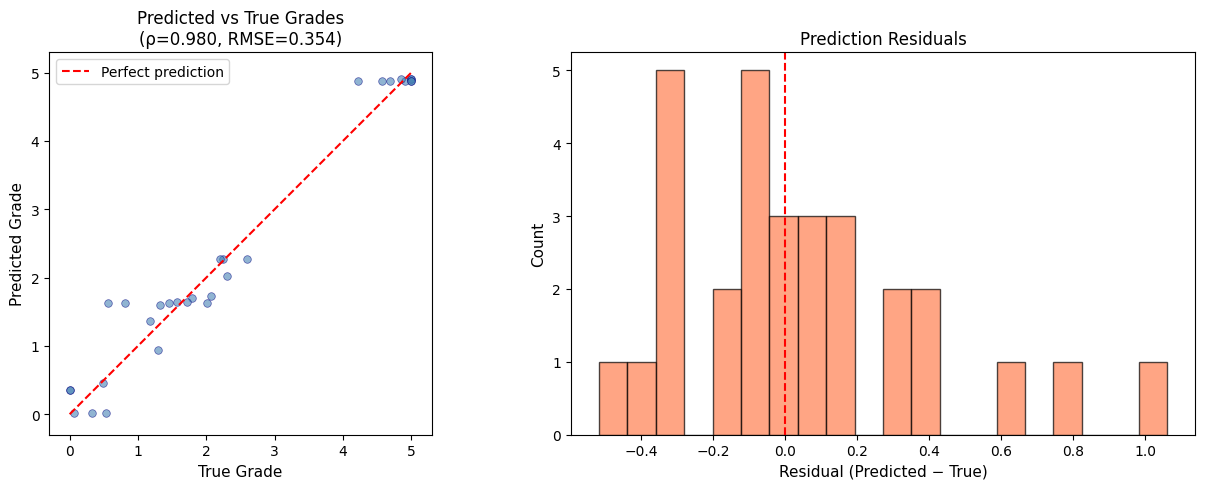


Plot saved to results/task2_results.png


In [7]:
# Generate predictions for the scatter plot
refs_test = test_df["reference_answer"].tolist()
stus_test = test_df["student_answer"].tolist()
y_true = test_df["grade"].to_numpy()
y_pred = grader.predict(refs_test, stus_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_true, y_pred, alpha=0.6, s=30, color="steelblue", edgecolors="navy", linewidth=0.5)
axes[0].plot([0, 5], [0, 5], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("True Grade", fontsize=11)
axes[0].set_ylabel("Predicted Grade", fontsize=11)
axes[0].set_title(f"Predicted vs True Grades\n(ρ={results['pearson']:.3f}, RMSE={results['rmse']:.3f})", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_xlim(-0.3, 5.3)
axes[0].set_ylim(-0.3, 5.3)
axes[0].set_aspect("equal")

# Residual distribution
residuals = y_pred - y_true
axes[1].hist(residuals, bins=20, edgecolor="black", alpha=0.7, color="coral")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residual (Predicted − True)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title("Prediction Residuals", fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "task2_results.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPlot saved to {RESULTS_DIR}/task2_results.png")

The scatter plot shows predicted vs true grades, with the red dashed line indicating perfect prediction. Points close to this line indicate accurate grading. The residual histogram shows the distribution of prediction errors, centred around zero for an unbiased model.